In [2]:
from kafka import KafkaConsumer, TopicPartition
import json
import numpy as np
import matplotlib.mlab as mlab
from sklearn.ensemble import IsolationForest
import os
import time
from datetime import datetime, timedelta
import matplotlib.pyplot as plt
from collections import defaultdict
from baskervillehall.baskervillehall_isolation_forest import BaskervillehallIsolationForest
from baskervillehall.model_io import ModelIO

plt.rcParams["figure.figsize"] = (15,5)

In [3]:
kafka_url = ['kafka9-0.kafka9-headless.default.svc.cluster.local:9093','kafka9-1.kafka9-headless.default.svc.cluster.local:9093','kafka9-2.kafka9-headless.default.svc.cluster.local:9093']
topic = 'BASKERVILLEHALL_3'

In [182]:
partitions = {
    'zhitomir.info': 1,
    'urban-pushkino.ru': 0,
    'dev.emawpb.org': 0,
    'palestinechronicle.com': 1,
    'equalit.ie': 0,
    'lexota.org': 0,
    'kavkaz-uzel.eu': 0,
    'amp.kavkaz-uzel.eu': 2,
    'indymedia.nl': 0,
    'btselem.org': 0,
    'verafiles.org': 1,
    'telegraf.in.ua': 2,
    'gubernia.com': 1
}

In [183]:
# host = 'kl.informator.ua'
host = 'gubernia.com'
# host = 'zhitomir.info'
# host = 'deflect.ca'
# host = 'btselem.org'
# host = 'nswp.org'
# host = 'indymedia.nl'
# host = 'urban-pushkino.ru'
# host = 'dev.emawpb.org'
# host = 'palestinechronicle.com'
# host = 'equalit.ie'
# host = 'lexota.org'
# host = 'kavkaz-uzel.eu'
# host = 'btselem.org'

dataset_size = 5000
datetime_format = '%Y-%m-%d %H:%M:%S'
path = 'anton/dataset/'

In [184]:
os.environ['S3_ACCESS'] = 'c490f17bdb784fa08f4d11836ee18e48'
os.environ['S3_SECRET'] = 'e4b65e27b3734d0d96ce6038586ef43f'
os.environ['S3_ENDPOINT'] = 's3.gra.cloud.ovh.net'
os.environ['S3_REGION'] = 'GRA'
s3_connection = {
    's3_access':os.environ['S3_ACCESS'],
    's3_secret':os.environ['S3_SECRET'],
    's3_endpoint': os.environ['S3_ENDPOINT'],
    's3_region':os.environ['S3_REGION']
}

In [185]:
def save_dataset(sessions, s3_connection, path, filename):
    model_io = ModelIO(**s3_connection)
    model_io._save_object(json.dumps(sessions, indent=2), os.path.join(path, filename))

def load_dataset(s3_connection, path, filename):
    model_io = ModelIO(**s3_connection)
    return json.loads(model_io._load_object(os.path.join(path, filename)))

In [210]:
def read_sessions(partition):
    consumer = KafkaConsumer(
        bootstrap_servers=kafka_url,
        group_id='anton11'
    )
    
    ids = []
    num = 0
    
    print(f'Reading from kafka. Host = {host} ... partition = {partition}')
    time_now = int(time.time())
    sessions = []

    consumer.assign([TopicPartition(topic, partition)])
    consumer.seek_to_beginning()
    complete = False
    while not complete:
        raw_messages = consumer.poll(timeout_ms=1000, max_records=5000)

        for topic_partition, messages in raw_messages.items():
            for message in messages:
                # prevent from getting messages too close to the current time
                time_diff_in_minutes = (time_now - message.timestamp / 1000) / 60
                if time_diff_in_minutes < 2:
                    print(f'{time_diff_in_minutes} minutes. Topic offset is too close to the current times...')
                    complete = True
                    break
                
                if message.value is None :
                    continue
                if message.key is None:
                    continue
                if message.key.decode("utf-8") != host:
                    continue

                value = json.loads(message.value.decode("utf-8"))
                value['duration'] = abs(value['duration'])
                duration = value['duration']
                if duration < 1:
                    continue
                if duration > 300:
                    continue
                if len(value['requests']) < 3:
                    continue
                    
                if len(sessions) == 0:
                    print(f'First session start = {value["start"]} end = {value["end"]}')
                    
                sessions.append(value)
                ids.append(value['ip'])
                if num == dataset_size:
                    complete = True
                    break
                num += 1
                if num % 100 == 0:
                    print(f'{num} sessions read', value['end'], message.timestamp)
            
    return np.array(ids), sessions



In [211]:
ids, sessions = read_sessions(partitions[host])

Reading from kafka. Host = gubernia.com ... partition = 1
First session start = 2023-12-26 12:14:13 end = 2023-12-26 12:14:24
100 sessions read 2023-12-26 13:20:41 1703596926529
200 sessions read 2023-12-26 14:19:24 1703600693874
300 sessions read 2023-12-26 15:37:16 1703605045268
400 sessions read 2023-12-26 17:24:35 1703611501857
500 sessions read 2023-12-26 18:25:47 1703615338624
600 sessions read 2023-12-26 20:24:29 1703622303062
700 sessions read 2023-12-26 21:32:22 1703626552612
800 sessions read 2023-12-26 22:53:51 1703631232507
900 sessions read 2023-12-26 23:28:23 1703633583212
1000 sessions read 2023-12-27 00:26:48 1703636825778
1100 sessions read 2023-12-27 01:28:02 1703640529041
1200 sessions read 2023-12-27 02:49:04 1703645346900
1300 sessions read 2023-12-27 03:48:11 1703648893856
1400 sessions read 2023-12-27 04:43:05 1703652252575
1500 sessions read 2023-12-27 05:22:28 1703654756857
1600 sessions read 2023-12-27 06:20:17 1703658270264
1700 sessions read 2023-12-27 07:21

In [188]:
# save_dataset(sessions, s3_connection, path, 'verafiles5000.json')

In [189]:
from sklearn.preprocessing import LabelEncoder

def calculate_features(sessions):
    vectors = []
    durations = []
    countries = []
    country_map = defaultdict(int)
    model = BaskervillehallIsolationForest(
        feature_names=features,
        categorical_feature_names=['country'],
        warmup_period=3
    )

    for session in sessions:
        session['duration'] = abs(session['duration'])
        duration = session['duration']
        if duration < 1:
            continue
        if duration > 300:
            continue
        if len(session['requests']) < 3:
            continue

        vector = model.get_features(
            model.preprocess_session(session)
        )
                            
        countries.append(session['country'])
        country_map[session['country']] += 1
            
        durations.append(session['duration'])

        vectors.append(vector)
            
    country_encoder = LabelEncoder()
    countries_encoded = country_encoder.fit_transform(countries)

    categorical_vectors = np.array([countries_encoded]).transpose()

    vectors = np.array(vectors)
    vectors = np.concatenate((vectors, categorical_vectors), axis=1)
    # vectors[:,-1] = countries_encoded
        
    return vectors, durations, country_encoder, country_map


In [190]:
warmup_period = 1
features = [
                'request_rate',
                # 'request_interval_average',
                # 'request_interval_std',
                'response4xx_to_request_ratio',
                # 'response5xx_to_request_ratio',
                'top_page_to_request_ratio',
                'unique_path_rate',
                'unique_path_to_request_ratio',
                # 'unique_query_rate',
                # 'unique_query_to_unique_path_ratio',
                'image_to_html_ratio',
                'js_to_html_ratio',
                # 'css_to_html_ratio',
                'path_depth_average',
                # 'path_depth_std',
                # 'payload_size_log_average',
                'fresh_session',
                'entropy'
]

In [191]:
vectors, durations, country_encoder, country_map = calculate_features(
    sessions
)

In [192]:
vectors.shape

(3828, 11)

In [193]:
len(sessions)

3828

In [194]:
session172 = sessions[172]

In [195]:
for i in range(len(sessions)):
    session = sessions[i]
    ts = datetime.strptime(session['end'], datetime_format)
    if ts.day == 27 and ts.hour == 3 and ts.minute == 43:
        print(i, session['start'], session['end'], session['duration'], session['session_id'])
        # print(session['requests'])
        # for r in session['requests']:
        #     print(r['ts'], r['url'])
        # print('******************** \n\n')
        break
        
    


2670 2023-12-27 03:39:27 2023-12-27 03:43:10 223.0 -


In [196]:
country_map

defaultdict(int,
            {'RU': 2379,
             'NO': 271,
             'US': 969,
             'DE': 9,
             'UA': 4,
             'FR': 46,
             '': 52,
             'CN': 10,
             'TH': 7,
             'TR': 19,
             'IT': 2,
             'IL': 3,
             'KZ': 3,
             'CA': 16,
             'BE': 2,
             'IE': 2,
             'BY': 6,
             'KH': 2,
             'MD': 4,
             'GB': 10,
             'FI': 4,
             'JP': 2,
             'NL': 2,
             'SG': 2,
             'TZ': 2})

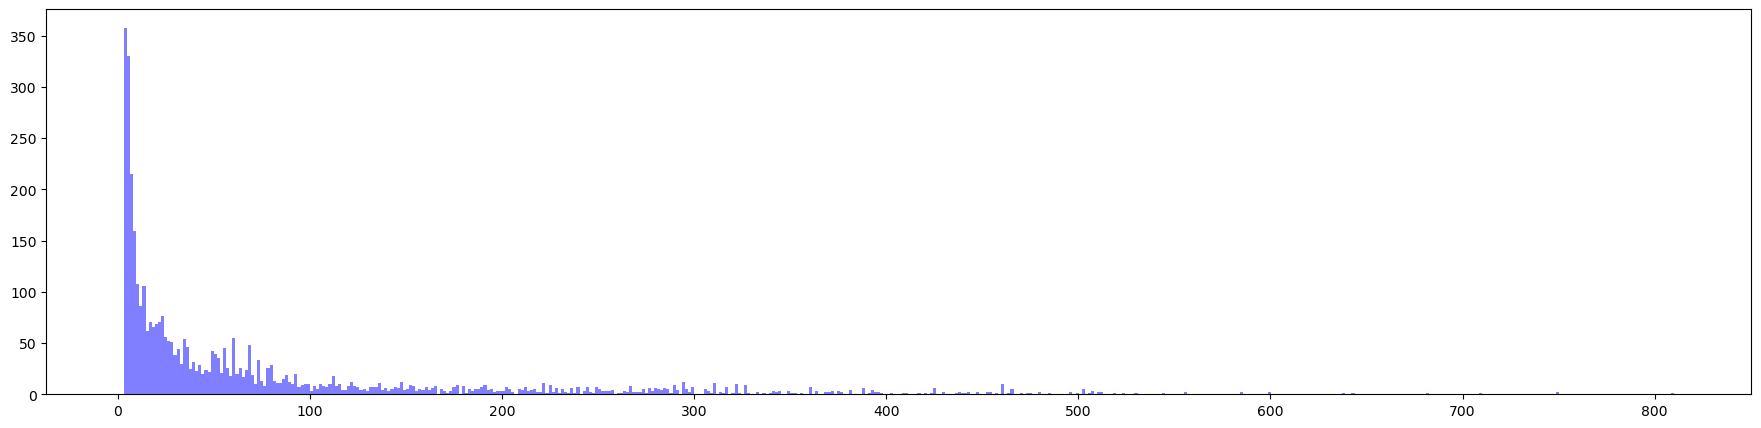

In [197]:
n, bins, patches = plt.hist([len(s['requests'])*60.0/s['duration'] for s in sessions], 500, facecolor='blue', alpha=0.5)
plt.rcParams["figure.figsize"] = (22,5)
plt.show()

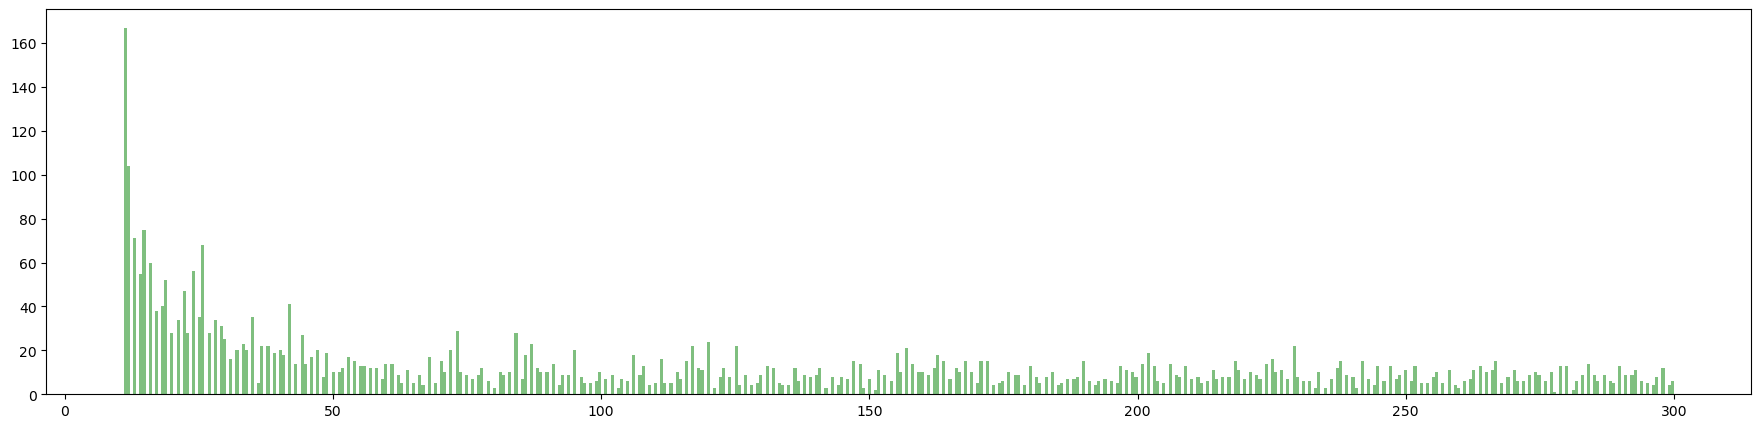

In [198]:
n, bins, patches = plt.hist(durations, 500, facecolor='green', alpha=0.5)
plt.rcParams["figure.figsize"] = (22,5)
plt.show()

In [199]:
vectors.shape

(3828, 11)

In [200]:
ids.shape

(3828,)

In [201]:
Y = np.array(vectors)
indices = np.random.permutation(Y.shape[0])
num_train = int(0.9 * Y.shape[0])
training_idx, validate_idx = indices[:num_train], indices[num_train:]
Y_train, ids_train = Y[training_idx, :], ids[training_idx]
Y_validate, ids_validate = Y[validate_idx, :], ids[validate_idx]

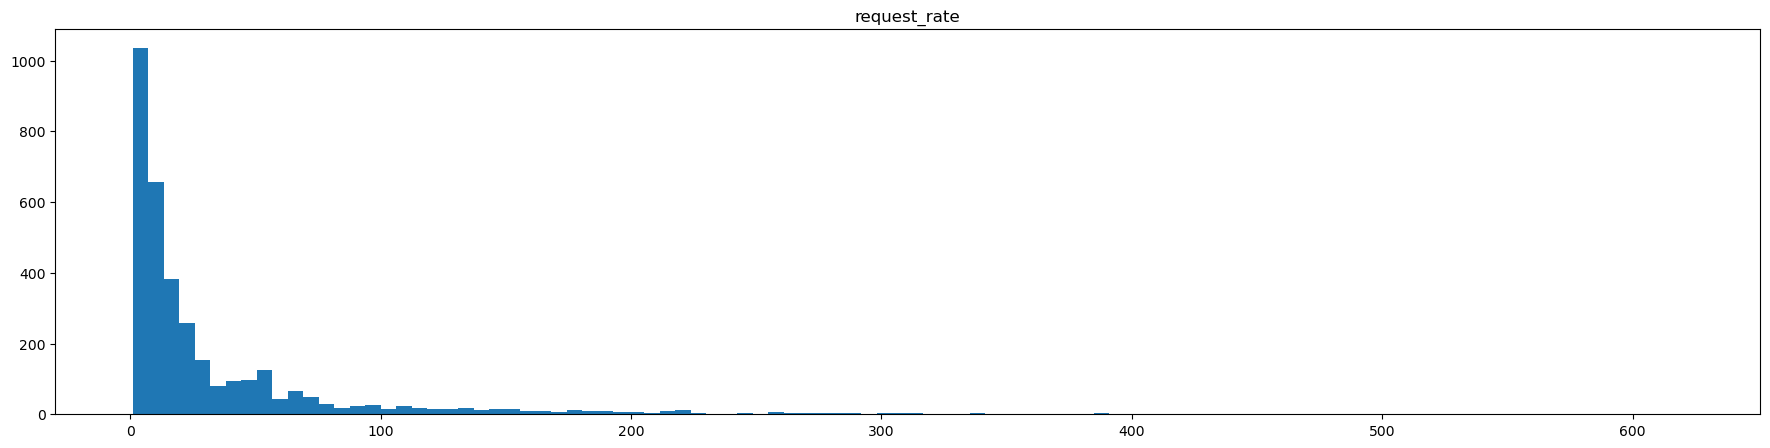

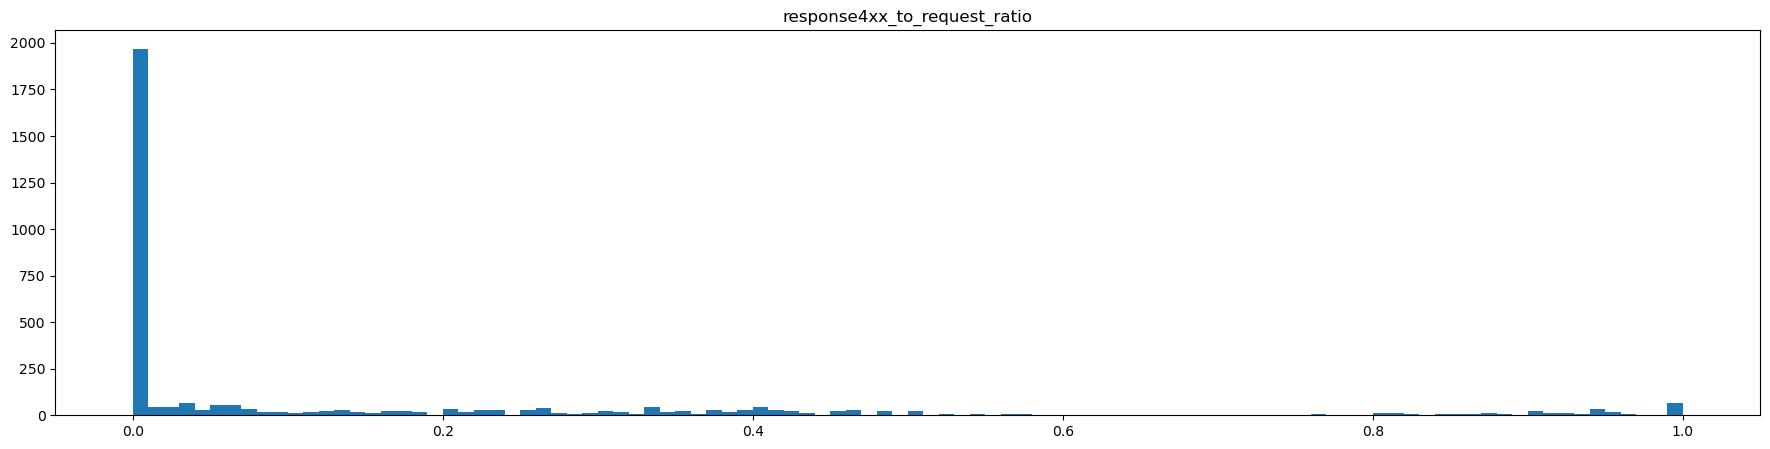

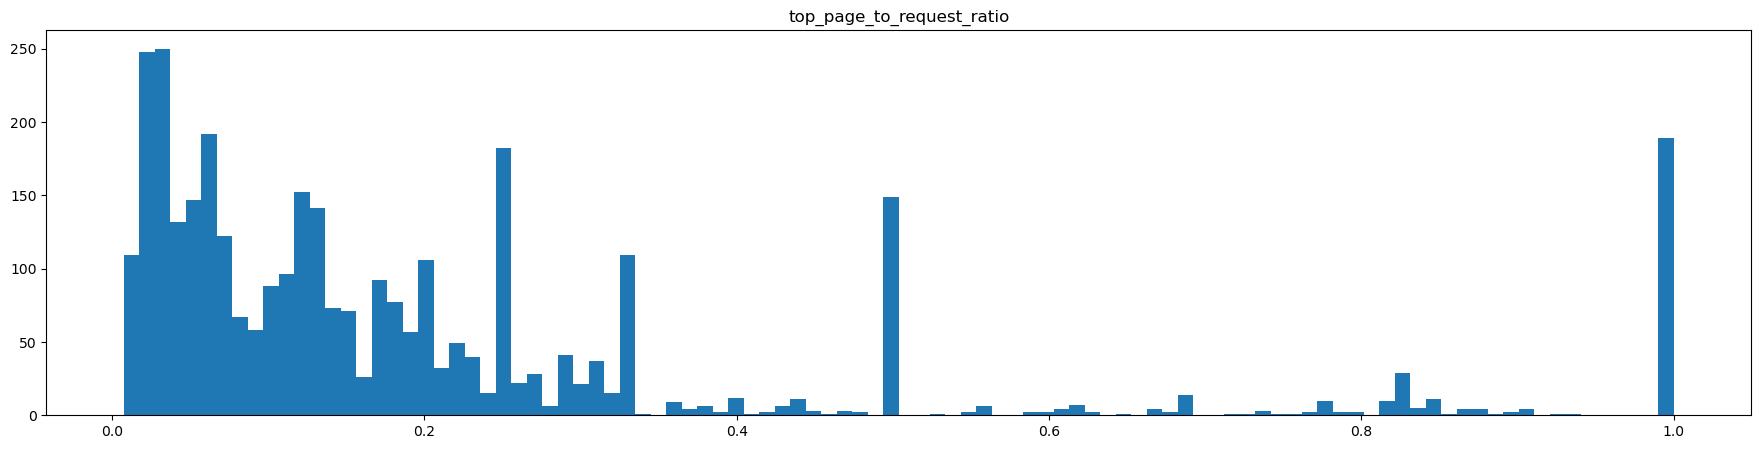

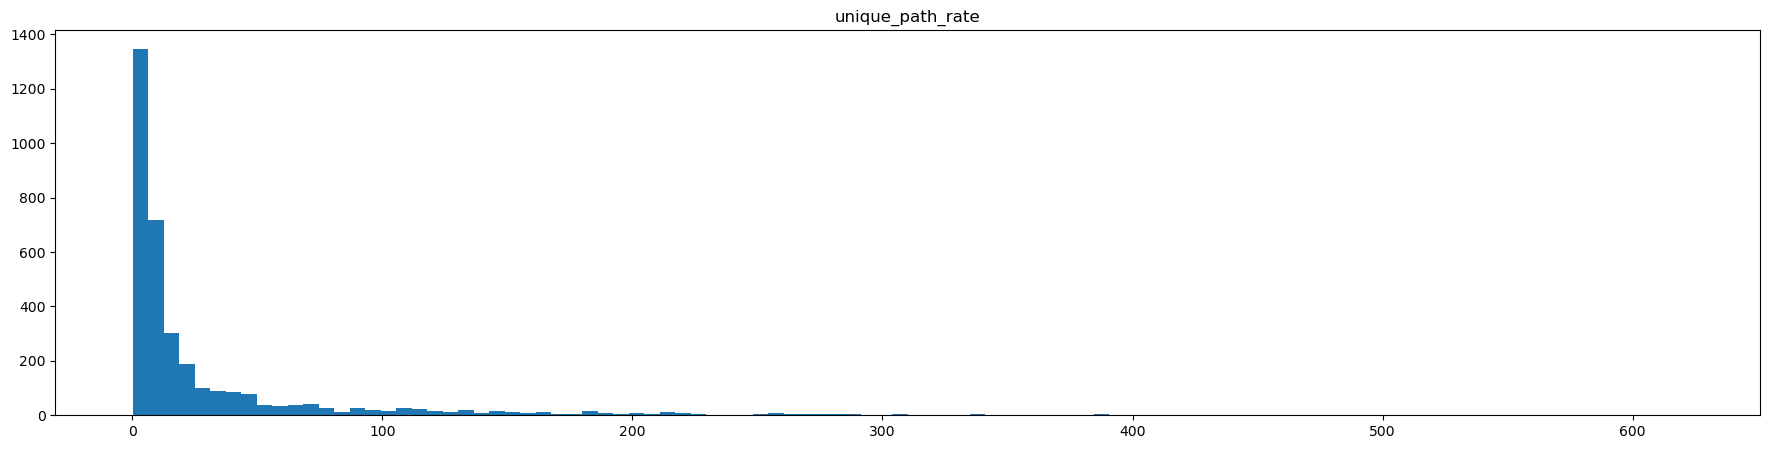

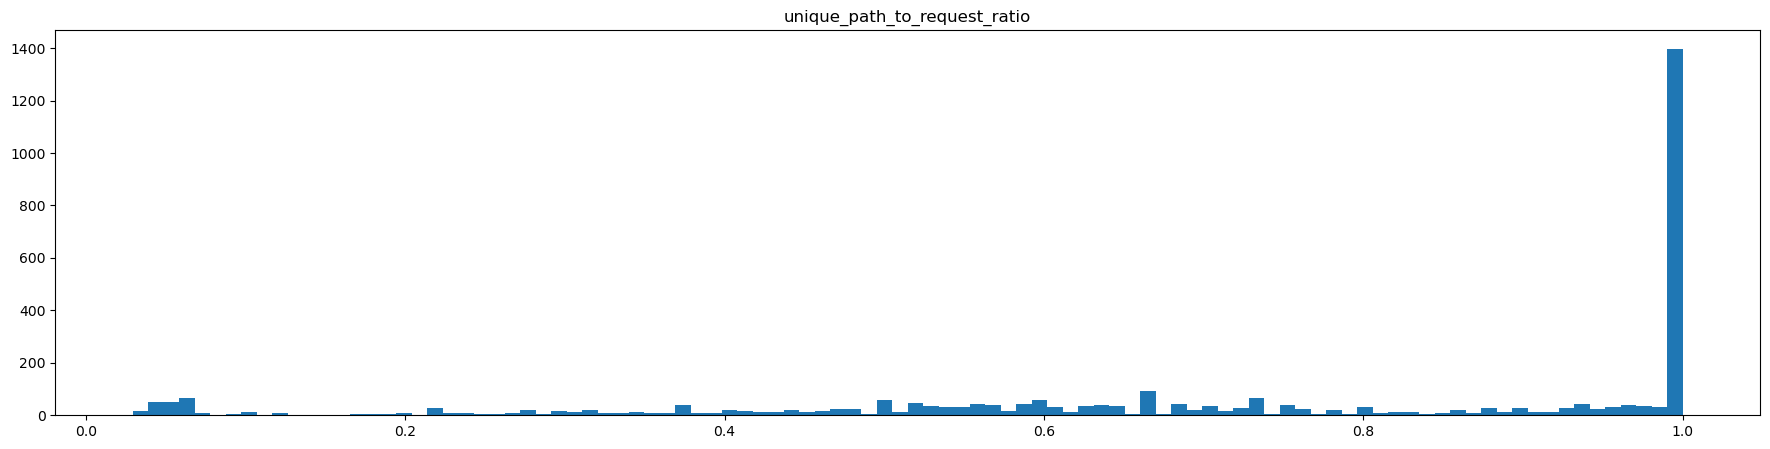

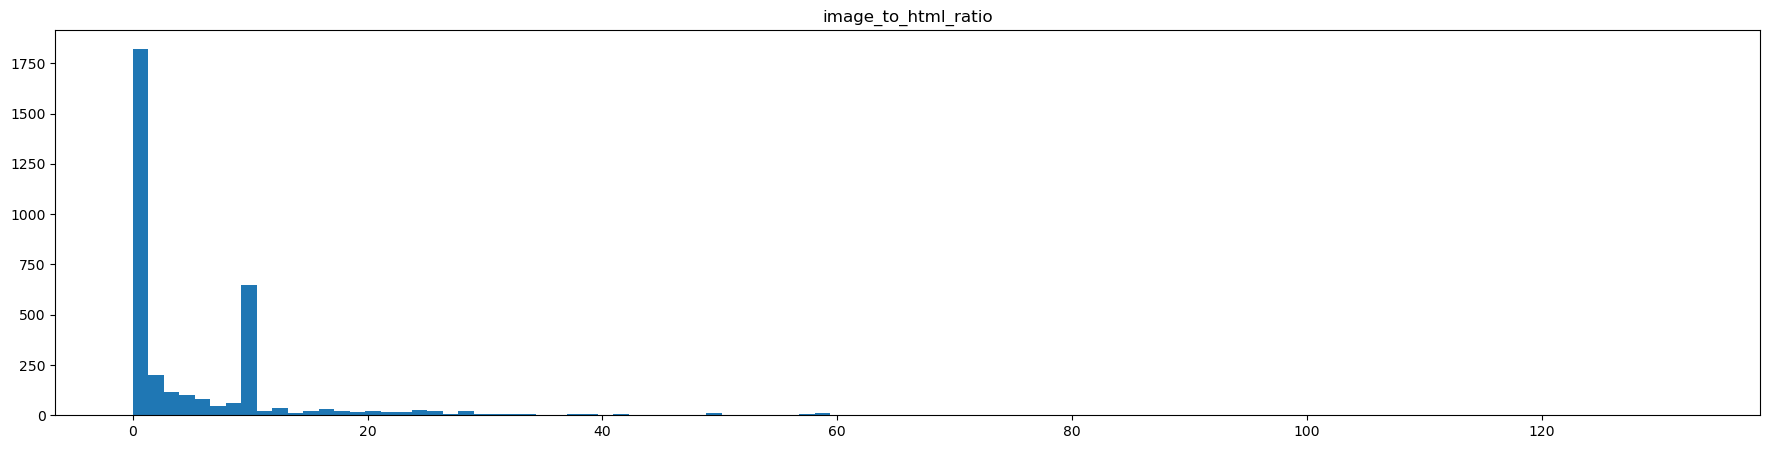

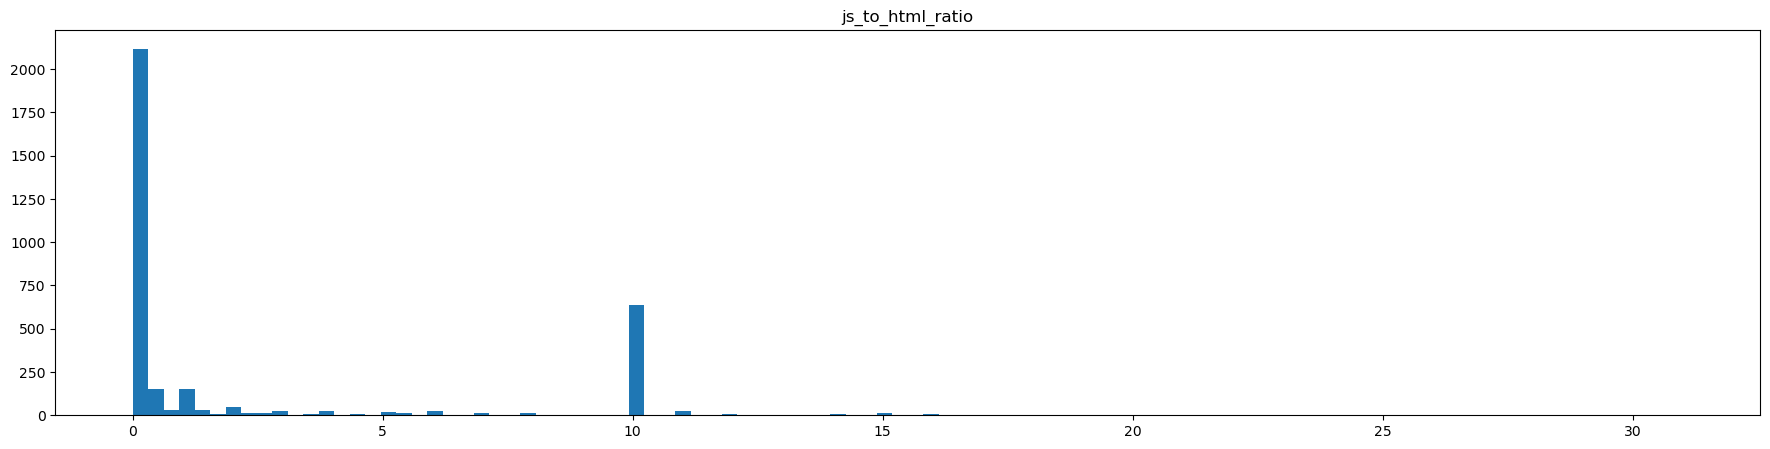

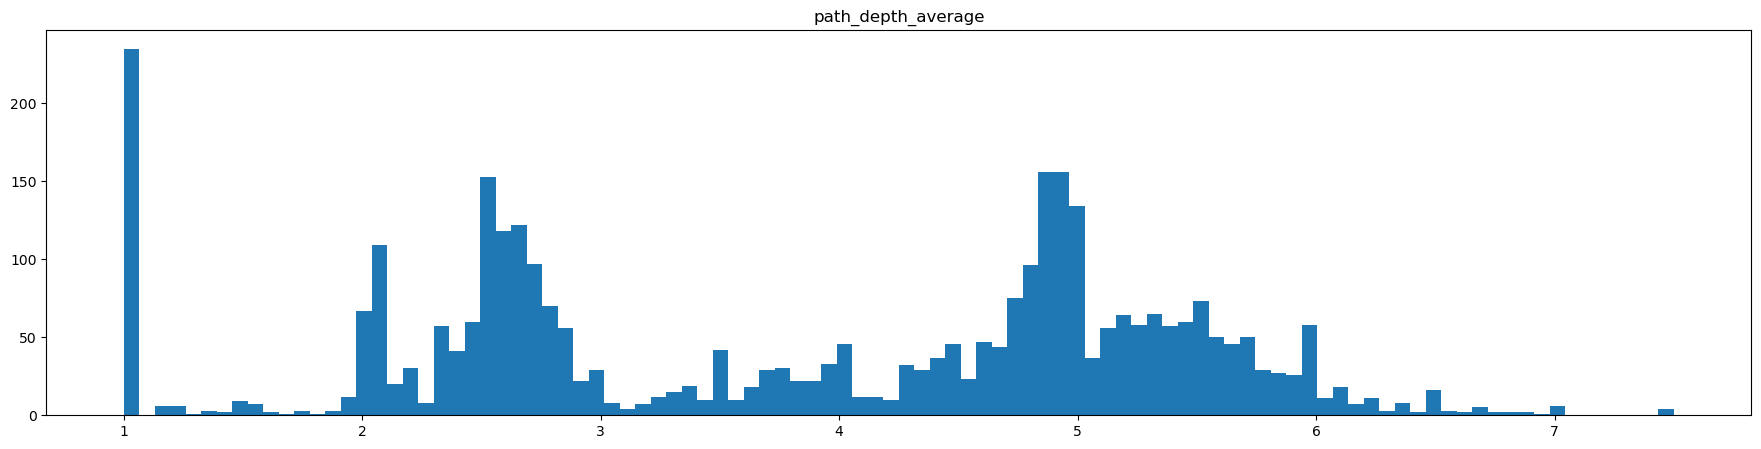

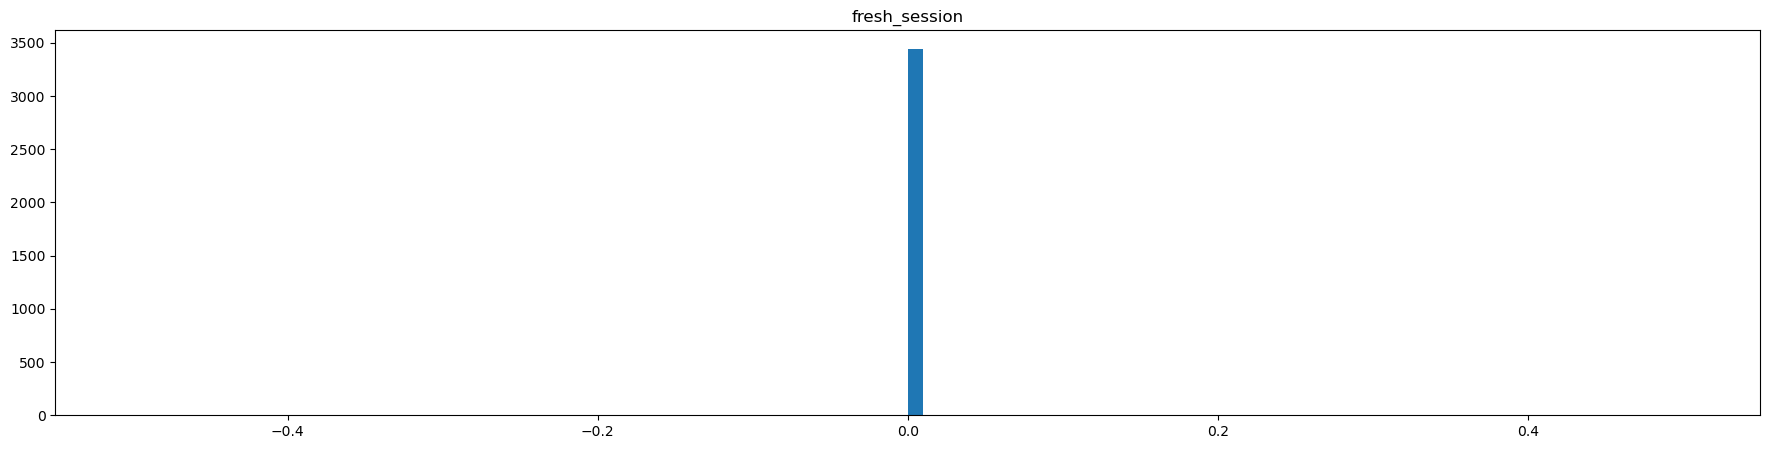

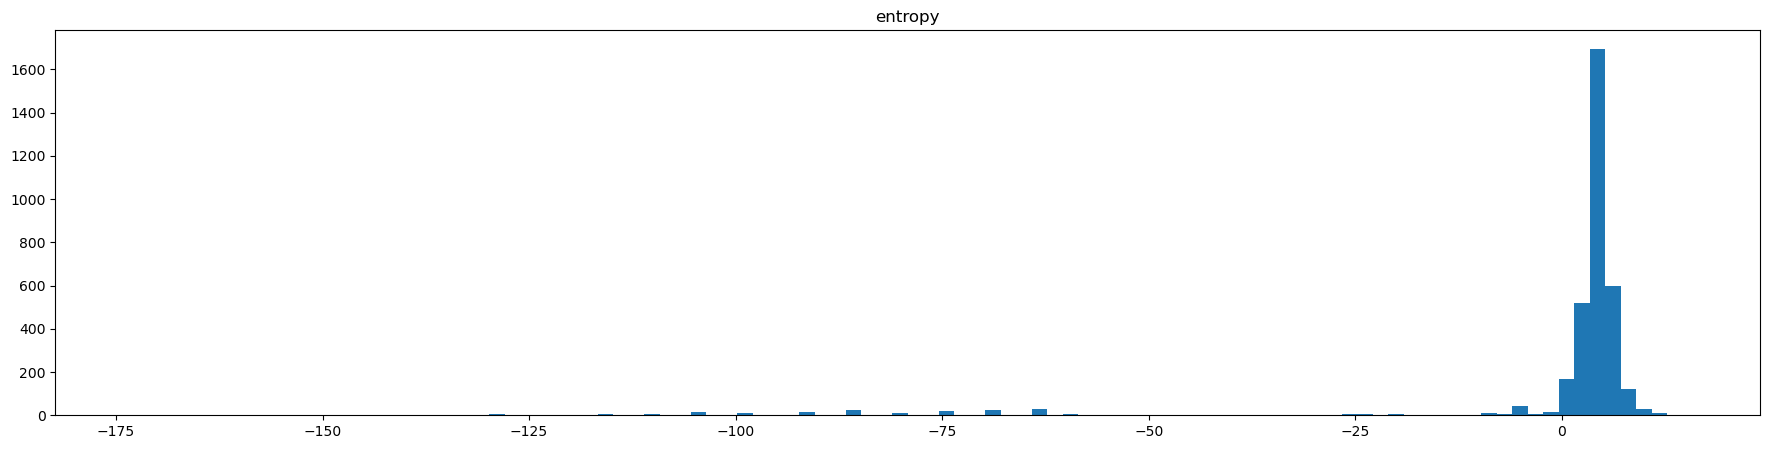

In [202]:
for i in range(len(features)):
    a = np.hstack(Y_train[:,i])
    _ = plt.hist(a, bins=100)  # arguments are passed to np.histogram
    plt.title(features[i])
    plt.show()

In [203]:
mean = Y_train.mean(axis=0)
std = Y_train.std(axis=0)
print(f'zero columns : {std[std == 0].shape}')
std[std == 0] = 1
Z_train = (Y_train - mean) / std
Z_train[np.isnan(Z_train)] = 0

Z_validate = (Y_validate - mean) / std
Z_validate[np.isnan(Z_validate)] = 0

zero columns : (1,)


In [204]:
mean.shape

(11,)

In [205]:
rf = IsolationForest(
    n_estimators = 3000,
    max_samples=2048, 
    max_features=0.8,
    random_state=0,
    contamination=0.07
)
rf.fit(Z_train)

IsolationForest(contamination=0.07, max_features=0.8, max_samples=2048,
                n_estimators=3000, random_state=0)

In [206]:
def fpr(x):
    return len(x[x < 0]) * 1.0 / len(x)

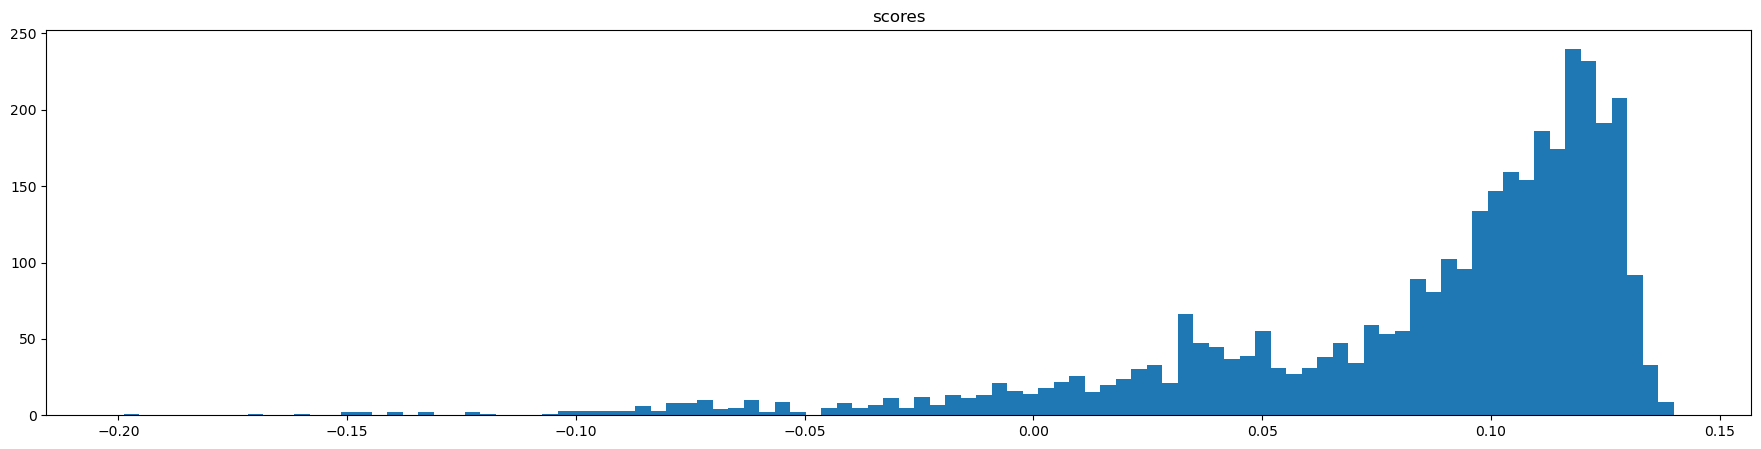

In [207]:
scores = rf.decision_function(Z_train)
a = np.hstack(scores)
_ = plt.hist(a, bins=100)  
plt.title('scores')
plt.show()

In [208]:
print(f'FPR train: {fpr(rf.predict(Z_train))}, validate: {fpr(rf.predict(Z_validate))}')

FPR train: 0.0702467343976778, validate: 0.0783289817232376


## Home page

In [209]:
duration = 60
hit_rate = 20
country = 'US'
url = '/'
session = {'duration': duration, 'country': country, 'fresh_sessions': False, 'session_id':'-'}
requests = []
num_hits = int(duration * hit_rate / 60)
ts = datetime.now()
time_increment = 60.0 / hit_rate
countries = []

for i in range(num_hits):
    requests.append({'ts': ts, 
                     # 'url': url, 
                     'url': f'{i}',
                     'query': '', 'code': 400, 'type': 'text/html','payload': 1000})
    ts += timedelta(seconds=time_increment)
    countries.append(country)
session['requests'] = requests

# session['requests'] = [
#     {'ts': '2023-10-12 21:04:20', 'url': '/wp-content/themes/mh-magazine-child/style.css', 'query': 'ver=1.6.75', 'code': 200, 'type': 'text/css', 'payload': 6595, 'fresh_session': False}, 
#     {'ts': '2023-10-12 21:04:20', 'url': '/wp-content/uploads/2021/01/palestine_chronicle_new_logo.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 45459, 'fresh_session': False}, {'ts': '2023-10-12 21:04:20', 'url': '/wp-content/themes/mh-magazine/js/scripts.js', 'query': 'ver=3.8.12', 'code': 200, 'type': 'application/javascript', 'payload': 13753, 'fresh_session': False}, {'ts': '2023-10-12 21:04:20', 'url': '/wp-content/plugins/super-rss-reader/public/js/script.min.js', 'query': 'ver=5.0', 'code': 200, 'type': 'application/javascript', 'payload': 803, 'fresh_session': False}, {'ts': '2023-10-12 21:04:20', 'url': '/wp-content/plugins/captcha/css/desktop_style.css', 'query': 'ver=4.4.5', 'code': 200, 'type': 'text/css', 'payload': 438, 'fresh_session': False}, {'ts': '2023-10-12 21:04:20', 'url': '/wp-content/plugins/captcha/css/front_end_style.css', 'query': 'ver=4.4.5', 'code': 200, 'type': 'text/css', 'payload': 762, 'fresh_session': False}, {'ts': '2023-10-12 21:04:20', 'url': '/wp-content/plugins/sharethis-share-buttons/css/mu-style.css', 'query': 'ver=1695397441', 'code': 200, 'type': 'text/css', 'payload': 26, 'fresh_session': False}, {'ts': '2023-10-12 21:04:20', 'url': '/wp-content/themes/mh-magazine/includes/font-awesome.min.css', 'query': '', 'code': 200, 'type': 'text/css', 'payload': 7949, 'fresh_session': False}, {'ts': '2023-10-12 21:04:20', 'url': '/wp-includes/css/dashicons.min.css', 'query': 'ver=6.3.1', 'code': 200, 'type': 'text/css', 'payload': 36701, 'fresh_session': False}, {'ts': '2023-10-12 21:04:20', 'url': '/wp-content/plugins/tabber-widget/js/jquery.idTabs.min.js', 'query': 'ver=6.3.1', 'code': 200, 'type': 'application/javascript', 'payload': 1095, 'fresh_session': False}, {'ts': '2023-10-12 21:04:20', 'url': '/wp-content/plugins/super-rss-reader/public/css/style.min.css', 'query': 'ver=5.0', 'code': 200, 'type': 'text/css', 'payload': 1256, 'fresh_session': False}, {'ts': '2023-10-12 21:04:20', 'url': '/wp-includes/js/jquery/jquery-migrate.min.js', 'query': 'ver=3.4.1', 'code': 200, 'type': 'application/javascript', 'payload': 5342, 'fresh_session': False}, {'ts': '2023-10-12 21:04:20', 'url': '/wp-content/themes/mh-magazine/style.css', 'query': 'ver=3.8.12', 'code': 200, 'type': 'text/css', 'payload': 19952, 'fresh_session': False}, {'ts': '2023-10-12 21:04:20', 'url': '/wp-content/plugins/super-rss-reader/public/js/jquery.easy-ticker.min.js', 'query': 'ver=5.0', 'code': 200, 'type': 'application/javascript', 'payload': 1200, 'fresh_session': False}, {'ts': '2023-10-12 21:04:20', 'url': '/wp-includes/js/jquery/jquery.min.js', 'query': 'ver=3.7.0', 'code': 200, 'type': 'application/javascript', 'payload': 35399, 'fresh_session': False}, {'ts': '2023-10-12 21:04:20', 'url': '/wp-content/plugins/wp-forecast/wp-forecast-default.css', 'query': 'ver=9999', 'code': 200, 'type': 'text/css', 'payload': 1049, 'fresh_session': False}, {'ts': '2023-10-12 21:04:20', 'url': '/wp-content/themes/mh-magazine-child/fontawesome.min.css', 'query': 'ver=6.4.0', 'code': 200, 'type': 'text/css', 'payload': 21078, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/themes/mh-magazine-child/support-the-palestine-chronicle.jpg', 'query': '', 'code': 200, 'type': 'image/jpeg', 'payload': 86349, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2023/10/Iran-Saudi-Arabia_101223-80x60.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 11256, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2022/06/Middle-Banner-1-768x308.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 126008, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2023/10/Gaza_water_crisis_101223-80x60.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 12535, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/plugins/page-links-to/dist/new-tab.js', 'query': 'ver=3.3.6', 'code': 200, 'type': 'application/javascript', 'payload': 10020, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2022/04/Lavrov-Hamas-80x60.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 10128, 'fresh_session': False}, {'ts': '2023-10-12 21:04:22', 'url': '/wp-includes/js/wp-emoji-release.min.js', 'query': 'ver=6.3.1', 'code': 200, 'type': 'application/javascript', 'payload': 5842, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2022/10/Halevi-80x60.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 9261, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2023/08/Saleh-al-Arouri2-80x60.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 9917, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2023/10/Gaza-war3_101223-1-80x60.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 12085, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2023/10/manar-02712810016081071979-80x60.jpg', 'query': '', 'code': 200, 'type': 'image/jpeg', 'payload': 1473, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2020/10/noam_chomksy.jpg', 'query': '', 'code': 200, 'type': 'image/jpeg', 'payload': 133953, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2023/05/Add-a-subheading-4.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 202616, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2023/05/pc_newsletter.jpg', 'query': '', 'code': 200, 'type': 'image/jpeg', 'payload': 85643, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2023/04/Small-Upper-Banner_thump.jpg', 'query': '', 'code': 200, 'type': 'image/jpeg', 'payload': 52548, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/plugins/akismet/_inc/akismet-frontend.js', 'query': 'ver=1695397293', 'code': 200, 'type': 'application/javascript', 'payload': 3520, 'fresh_session': False}, {'ts': '2023-10-12 21:04:22', 'url': '/wp-content/uploads/2023/10/white-phosphorous.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 243872, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2023/10/Shifa_Burial_large_101223-80x60.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 11090, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2021/05/Canada-protest-80x60.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 12098, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/themes/mh-magazine/fonts/fontawesome-webfont.woff2', 'query': 'v=4.7.0', 'code': 200, 'type': 'application/octet-stream', 'payload': 77160, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2023/10/South-Afric_Solidarity-80x60.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 12558, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2019/06/Israeli-airstrikes-Syria-326x245.jpg', 'query': '', 'code': 200, 'type': 'image/jpeg', 'payload': 9023, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2023/10/WestBank_Soldiers_File_101223-80x60.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 11279, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-includes/js/comment-reply.min.js', 'query': 'ver=6.3.1', 'code': 200, 'type': 'application/javascript', 'payload': 1400, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/plugins/captcha/js/front_end_script.js', 'query': 'ver=6.3.1', 'code': 200, 'type': 'application/javascript', 'payload': 1102, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2023/10/Netanyahu-war-1-80x60.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 11806, 'fresh_session': False}, {'ts': '2023-10-12 21:04:21', 'url': '/wp-content/uploads/2021/01/palestine_chronicle_footer_new_logo.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 35257, 'fresh_session': False}, {'ts': '2023-10-12 21:04:23', 'url': '/wp-content/uploads/2023/10/Gaza-4day.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 501075, 'fresh_session': False}, {'ts': '2023-10-12 21:04:24', 'url': '/wp-content/uploads/2021/01/cropped-palestine_chronicle_footer_new_logo-32x32.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 2170, 'fresh_session': False}, {'ts': '2023-10-12 21:05:22', 'url': '/wp-content/uploads/2020/03/Gaza-7-326x245.jpg', 'query': '', 'code': 200, 'type': 'image/jpeg', 'payload': 16304, 'fresh_session': False}, {'ts': '2023-10-12 21:05:23', 'url': '/wp-content/uploads/2020/11/Border-326x245.png', 'query': '', 'code': 200, 'type': 'image/png', 'payload': 160445, 'fresh_session': False}]

# session['requests'] = [{'ts': '2023-10-09 13:29:17', 'url': '/america-and-iran-a-history-1720-to-the-present-book-review/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 26480, 'fresh_session': True}, {'ts': '2023-10-09 13:29:23', 'url': '/contact-us/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 25372, 'fresh_session': True}, {'ts': '2023-10-09 13:29:29', 'url': '/netanyahus-impossible-options-in-gaza-to-invade-or-not-to-invade/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 25849, 'fresh_session': True}, {'ts': '2023-10-09 13:29:34', 'url': '/palestinian-teenager-shot-and-killed-in-hebron/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 23425, 'fresh_session': True}, {'ts': '2023-10-09 13:29:40', 'url': '/thousands-killed-wounded-on-both-sides-al-aqsa-flood-escalates-live-blog/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 27741, 'fresh_session': True}, {'ts': '2023-10-09 13:29:46', 'url': '/thousands-killed-wounded-on-both-sides-al-aqsa-flood-escalates-live-blog/embed/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 7547, 'fresh_session': True}, {'ts': '2023-10-09 13:29:52', 'url': '/more-bad-news-for-israeli-economy-what-is-happening-to-shekel/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 23748, 'fresh_session': True}, {'ts': '2023-10-09 13:29:58', 'url': '/2023/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 25734, 'fresh_session': True}, {'ts': '2023-10-09 13:30:04', 'url': '/al-aqsa-flood-operation-continues-israeli-airstrikes-kill-hundreds-in-gaza-live-blog/embed/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 7632, 'fresh_session': True}, {'ts': '2023-10-09 13:30:10', 'url': '/89634-2/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 25025, 'fresh_session': True}, {'ts': '2023-10-09 13:30:16', 'url': '/al-aqsa-flood-operation-continues-israeli-airstrikes-kill-hundreds-in-gaza-live-blog/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 30433, 'fresh_session': True}, {'ts': '2023-10-09 13:30:22', 'url': '/demographic-war-why-some-palestinians-demolish-their-own-homes/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 23382, 'fresh_session': True}, {'ts': '2023-10-09 13:30:27', 'url': '/breaking-us-officials-claim-israel-will-launch-ground-operation-in-gaza-in-48-hours/embed/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 7575, 'fresh_session': True}, {'ts': '2023-10-09 13:30:33', 'url': '/leave-egypt-israel-tells-its-citizens-to-return-following-deadly-attack/embed/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 7592, 'fresh_session': True}, {'ts': '2023-10-09 13:30:39', 'url': '/this-is-what-israels-war-on-gaza-is-doing-photo-story/embed/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 7547, 'fresh_session': True}, {'ts': '2023-10-09 13:30:44', 'url': '/we-support-palestinians-right-to-self-defense-irans-president-speaks-to-hamas-leaders/embed/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 7646, 'fresh_session': True}, {'ts': '2023-10-09 13:30:50', 'url': '/breaking-us-officials-claim-israel-will-launch-ground-operation-in-gaza-in-48-hours/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 24328, 'fresh_session': True}, {'ts': '2023-10-09 13:30:56', 'url': '/leave-egypt-israel-tells-its-citizens-to-return-following-deadly-attack/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 24472, 'fresh_session': True}, {'ts': '2023-10-09 13:31:02', 'url': '/hezbollah-launches-new-attacks-targeting-israeli-positions-in-shebaa-farms/embed/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 7568, 'fresh_session': True}, {'ts': '2023-10-09 13:31:07', 'url': '/this-is-what-israels-war-on-gaza-is-doing-photo-story/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 24243, 'fresh_session': True}, {'ts': '2023-10-09 13:31:13', 'url': '/hezbollah-launches-new-attacks-targeting-israeli-positions-in-shebaa-farms/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 24568, 'fresh_session': True}, {'ts': '2023-10-09 13:31:19', 'url': '/we-support-palestinians-right-to-self-defense-irans-president-speaks-to-hamas-leaders/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 24645, 'fresh_session': True}, {'ts': '2023-10-09 13:31:25', 'url': '/avenging-the-free-thousands-of-palestinians-rally-in-palestine-lebanon-and-syria-photos/embed/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 7583, 'fresh_session': True}, {'ts': '2023-10-09 13:31:31', 'url': '/war-crimes-this-is-how-israel-demolishes-palestinian-homes-in-the-occupied-west-bank-photos/embed/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 7589, 'fresh_session': True}, {'ts': '2023-10-09 13:31:36', 'url': '/israeli-authorities-demolish-five-palestinian-homes-in-naqab/embed/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 7481, 'fresh_session': True}, {'ts': '2023-10-09 13:31:42', 'url': '/israel-to-demolish-residential-building-in-northern-jordan-valley/embed/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 7509, 'fresh_session': True}, {'ts': '2023-10-09 13:31:48', 'url': '/avenging-the-free-thousands-of-palestinians-rally-in-palestine-lebanon-and-syria-photos/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 18639, 'fresh_session': True}, {'ts': '2023-10-09 13:31:54', 'url': '/war-crimes-this-is-how-israel-demolishes-palestinian-homes-in-the-occupied-west-bank-photos/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 20998, 'fresh_session': True}, {'ts': '2023-10-09 13:32:00', 'url': '/israeli-authorities-demolish-five-palestinian-homes-in-naqab/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 21801, 'fresh_session': True}, {'ts': '2023-10-09 13:32:07', 'url': '/israel-to-demolish-residential-building-in-northern-jordan-valley/', 'query': '', 'code': 200, 'type': 'text/html', 'payload': 22322, 'fresh_session': True}]

model = BaskervillehallIsolationForest(
    feature_names=features,
    categorical_feature_names=['country'],
    warmup_period=warmup_period
)
session_features = model.calculate_features_dict(model.preprocess_session(session))
vector = model.get_vector_from_features_dict(session_features)
vector = np.append(vector, 0)
print(vector)
Y1 = np.array([vector for i in range(1)])
Y1[:, -1] = country_encoder.transform([country])
Z1 = (Y1 - mean) / std

ts = datetime.now()
score=rf.decision_function(Z1)[0]
print(score)
print(f'timer = {(datetime.now()-ts).total_seconds()}')


[20.          1.          0.05       20.          1.          0.
  0.          0.          0.          4.32192809  0.        ]
-0.013821150698652307
timer = 0.067597


In [52]:
model = BaskervillehallIsolationForest(
    feature_names=features,
    categorical_feature_names=['country'],
    warmup_period = warmup_period
)
session_features = model.calculate_features_dict(session)
vector = model.get_vector_from_features_dict(session_features)
vector = np.append(vector, 0)
# print(vector)
Y1 = np.array([vector for i in range(1)])
Y1[:, -1] = country_encoder.transform([country])
Z1 = (Y1 - mean) / std

ts = datetime.now()
score=rf.decision_function(Z1)[0]
print(score)
print(f'timer = {(datetime.now()-ts).total_seconds()}')


TypeError: unsupported operand type(s) for -: 'str' and 'str'

In [30]:
model.calculate_features_dict(session, datetime_format)

{'request_rate': 1472.7272727272727,
 'request_interval_average': 0.025925925925925925,
 'request_interval_std': 0.9205845938929412,
 'response4xx_to_request_ratio': 0.0,
 'response5xx_to_request_ratio': 0.0,
 'top_page_to_request_ratio': 0.03333333333333333,
 'unique_path_rate': 943.6363636363636,
 'unique_path_to_request_ratio': 0.6407407407407407,
 'unique_query_rate': 54.54545454545455,
 'unique_query_to_unique_path_ratio': 0.057803468208092484,
 'image_to_html_ratio': 0.0,
 'js_to_html_ratio': 0.0,
 'css_to_html_ratio': 0.0,
 'path_depth_average': 1.9666666666666666,
 'path_depth_std': 0.17950549357115012,
 'payload_size_log_average': 8.933575517306064,
 'fresh_session': 0,
 'entropy': 10.409365875427362}

In [31]:
session_features

{'request_rate': 1472.7272727272727,
 'request_interval_average': 0.025925925925925925,
 'request_interval_std': 0.9205845938929412,
 'response4xx_to_request_ratio': 0.0,
 'response5xx_to_request_ratio': 0.0,
 'top_page_to_request_ratio': 0.03333333333333333,
 'unique_path_rate': 943.6363636363636,
 'unique_path_to_request_ratio': 0.6407407407407407,
 'unique_query_rate': 54.54545454545455,
 'unique_query_to_unique_path_ratio': 0.057803468208092484,
 'image_to_html_ratio': 0.0,
 'js_to_html_ratio': 0.0,
 'css_to_html_ratio': 0.0,
 'path_depth_average': 1.9666666666666666,
 'path_depth_std': 0.17950549357115012,
 'payload_size_log_average': 8.933575517306064,
 'fresh_session': 0,
 'entropy': 10.409365875427362}

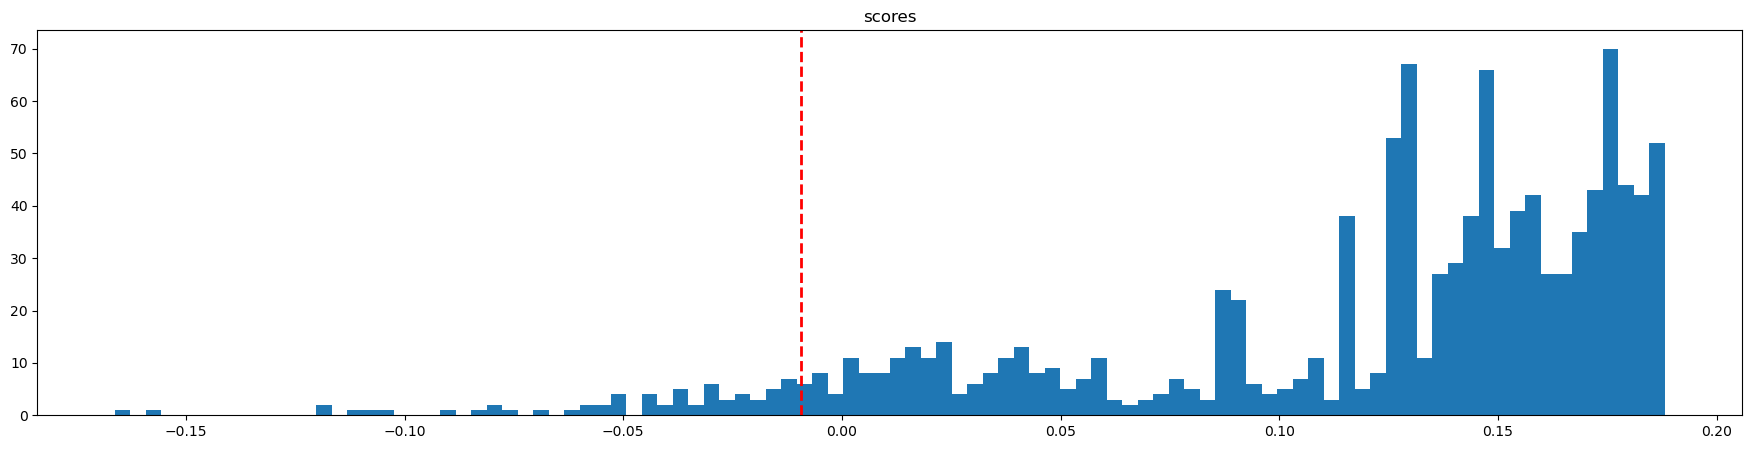

In [32]:
a = np.hstack(scores)
_ = plt.hist(a, bins=100)  
plt.axvline(score, color='red', linestyle='dashed', linewidth=2)
plt.title('scores')
plt.show()

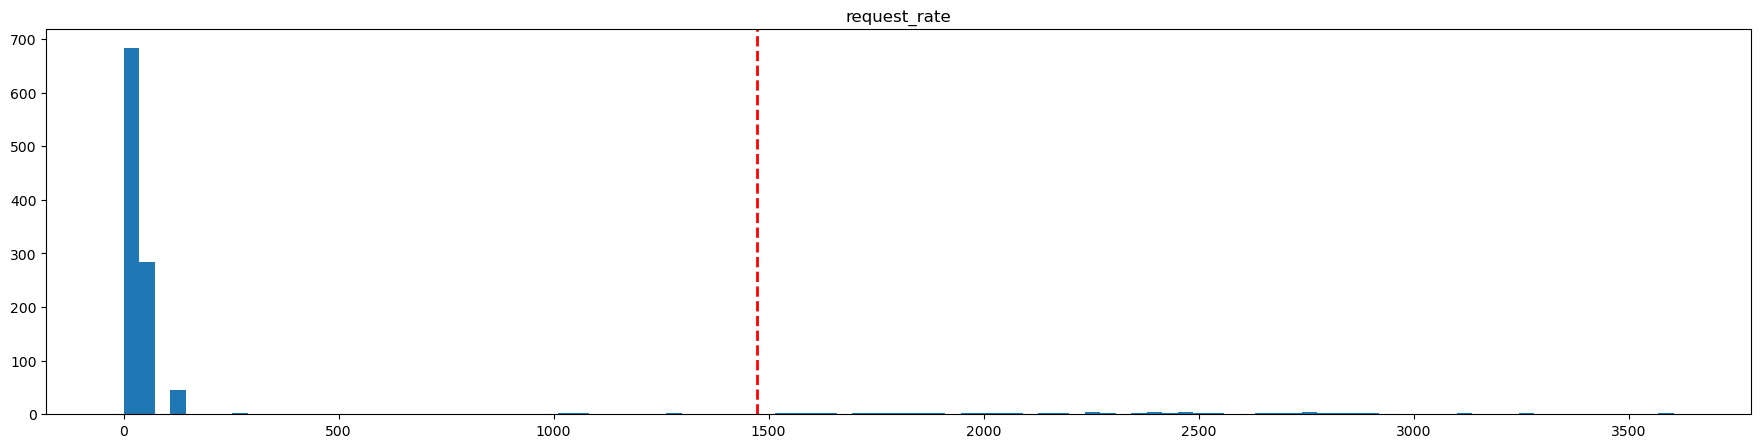

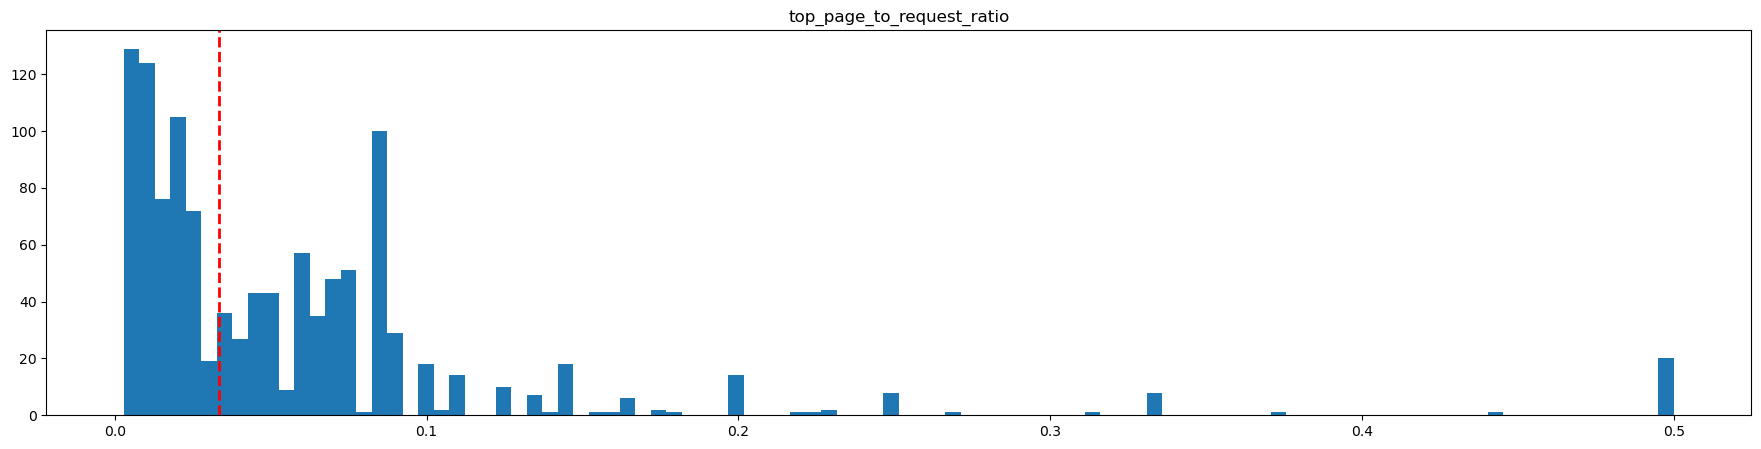

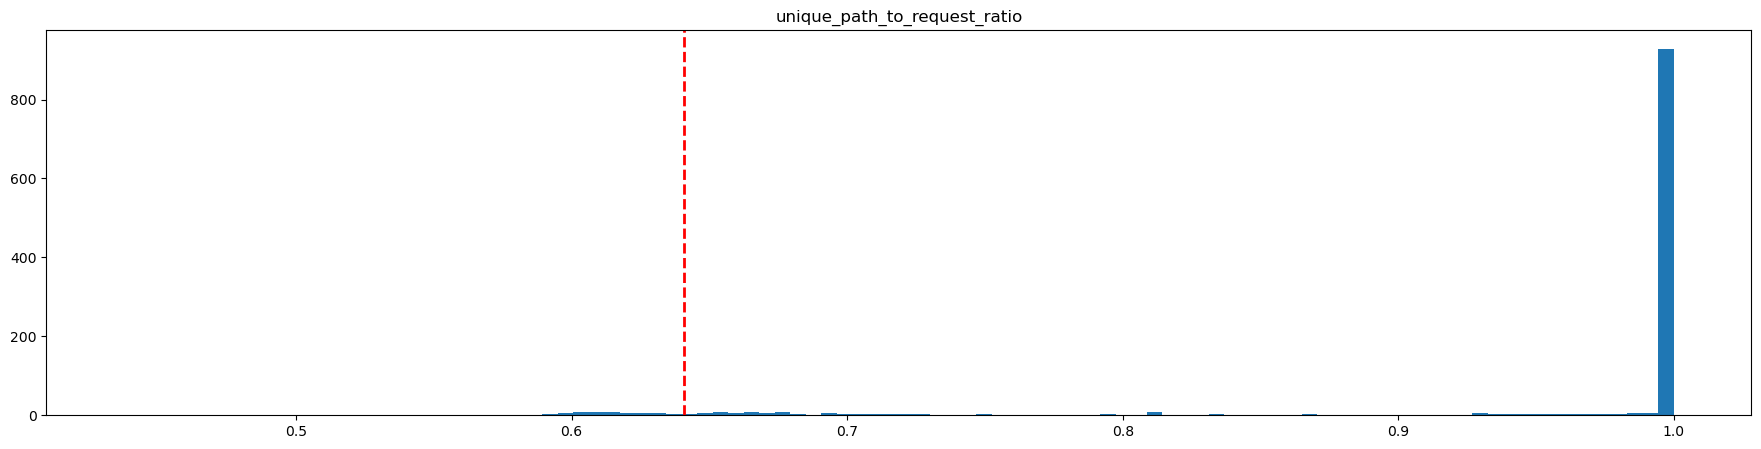

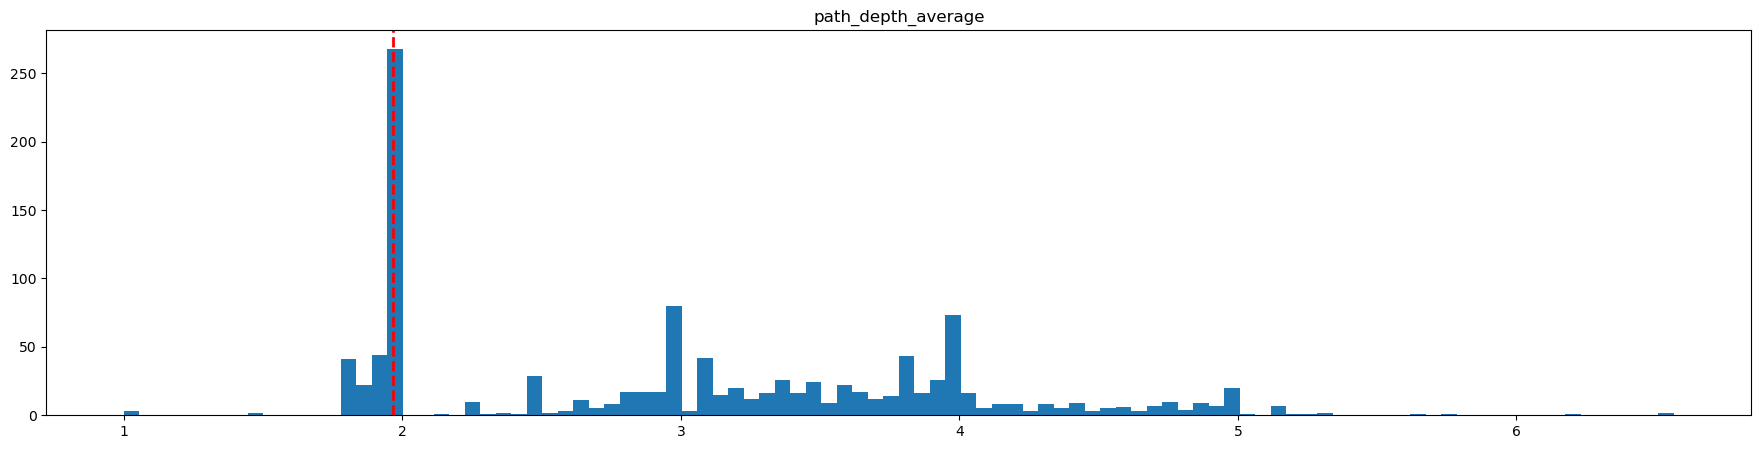

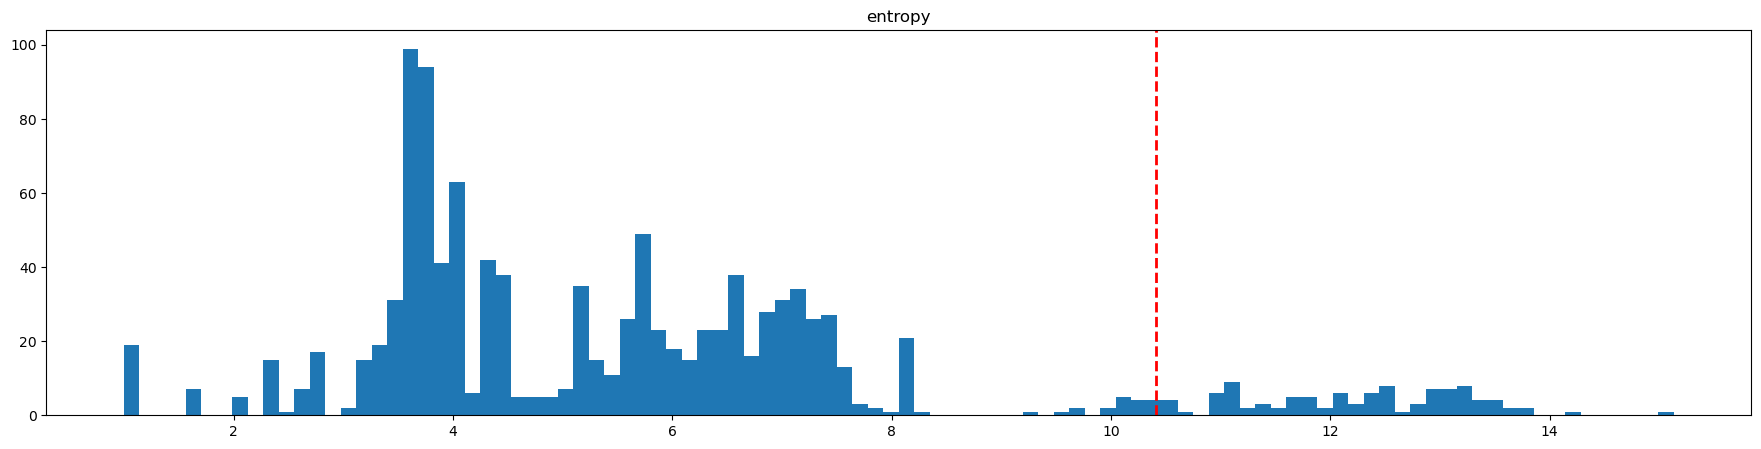

In [33]:
import matplotlib.pyplot as plt

for i in range(len(features)):
    a = np.hstack(Y_train[:,i])
    _ = plt.hist(a, bins=100)  # arguments are passed to np.histogram
    plt.title(features[i])
    plt.axvline(session_features[features[i]], color='red', linestyle='dashed', linewidth=2)
    plt.show()

In [196]:
session = sessions[0]
intervals = []
timestamps = [datetime.strptime(r['ts'], datetime_format) for r in session['requests']]
for i in range(len(session['requests'])):
    request = session['requests'][i]
    if i == 0:
        intervals.append(0)
    else:
        intervals.append((timestamps[i] - timestamps[i-1]).total_seconds())

In [197]:
timestamps


[datetime.datetime(2023, 11, 27, 3, 31, 30),
 datetime.datetime(2023, 11, 27, 3, 31, 32),
 datetime.datetime(2023, 11, 27, 3, 31, 32),
 datetime.datetime(2023, 11, 27, 3, 31, 31),
 datetime.datetime(2023, 11, 27, 3, 31, 31),
 datetime.datetime(2023, 11, 27, 3, 31, 31),
 datetime.datetime(2023, 11, 27, 3, 31, 34),
 datetime.datetime(2023, 11, 27, 3, 31, 33),
 datetime.datetime(2023, 11, 27, 3, 31, 34),
 datetime.datetime(2023, 11, 27, 3, 31, 33),
 datetime.datetime(2023, 11, 27, 3, 31, 35),
 datetime.datetime(2023, 11, 27, 3, 31, 35),
 datetime.datetime(2023, 11, 27, 3, 31, 36),
 datetime.datetime(2023, 11, 27, 3, 31, 36),
 datetime.datetime(2023, 11, 27, 3, 31, 37),
 datetime.datetime(2023, 11, 27, 3, 31, 38),
 datetime.datetime(2023, 11, 27, 3, 31, 37),
 datetime.datetime(2023, 11, 27, 3, 31, 38),
 datetime.datetime(2023, 11, 27, 3, 31, 40),
 datetime.datetime(2023, 11, 27, 3, 31, 39),
 datetime.datetime(2023, 11, 27, 3, 31, 39),
 datetime.datetime(2023, 11, 27, 3, 31, 40),
 datetime.